# Lab 4: Data Quality Assessment & Preprocessing

In [107]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [108]:
sns.set()
student_df = pd.read_csv(r"data.csv", sep=";") # load dataset

student_df.head() # print first 5 rows

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


# Identifying data quality issues (Task 1)

In [109]:
student_df.dtypes # check if datatypes match the columns

Marital status                                      int64
Application mode                                    int64
Application order                                   int64
Course                                              int64
Daytime/evening attendance\t                        int64
Previous qualification                              int64
Previous qualification (grade)                    float64
Nacionality                                         int64
Mother's qualification                              int64
Father's qualification                              int64
Mother's occupation                                 int64
Father's occupation                                 int64
Admission grade                                   float64
Displaced                                           int64
Educational special needs                           int64
Debtor                                              int64
Tuition fees up to date                             int64
Gender        

In [110]:
print(student_df[student_df.duplicated()]) # checking duplicate rows

Empty DataFrame
Columns: [Marital status, Application mode, Application order, Course, Daytime/evening attendance	, Previous qualification, Previous qualification (grade), Nacionality, Mother's qualification, Father's qualification, Mother's occupation, Father's occupation, Admission grade, Displaced, Educational special needs, Debtor, Tuition fees up to date, Gender, Scholarship holder, Age at enrollment, International, Curricular units 1st sem (credited), Curricular units 1st sem (enrolled), Curricular units 1st sem (evaluations), Curricular units 1st sem (approved), Curricular units 1st sem (grade), Curricular units 1st sem (without evaluations), Curricular units 2nd sem (credited), Curricular units 2nd sem (enrolled), Curricular units 2nd sem (evaluations), Curricular units 2nd sem (approved), Curricular units 2nd sem (grade), Curricular units 2nd sem (without evaluations), Unemployment rate, Inflation rate, GDP, Target]
Index: []

[0 rows x 37 columns]


In [111]:
print(student_df.isna().sum()) # get total number of missing values

Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance\t                      0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                                0
Age at enrol

# Mappings
(to fix incorrect datatypes)

In [112]:
# Mappings 
nominal_features = [
    'Marital status', 'Application mode', 'Course', 
    'Nacionality', "Mother's occupation", "Father's occupation"
]

binary_features = [
    'Displaced', 'Educational special needs', 'Debtor', 
    'Tuition fees up to date', 'Scholarship holder', 'International'
]

ordinal_features = [
    'Application order', 'Previous qualification', 
    "Mother's qualification", "Father's qualification"
]

continuous_features = [
    'Previous qualification (grade)', 'Admission grade', 
    'Curricular units 1st sem (grade)', 'Curricular units 2nd sem (grade)',
    'Unemployment rate', 'Inflation rate', 'GDP', 'Age at enrollment'
]

# Remove any potential whitespaces to avoid issues
student_df.columns = student_df.columns.str.strip()

# Map data to categories used by dataset
mappings = {
    'Marital status': {
        1: 'single', 2: 'married', 3: 'widower', 
        4: 'divorced', 5: 'facto union', 6: 'legally separated'
    },
    'Application mode': {
        1: '1st phase - general contingent',
        2: 'Ordinance No. 612/93',
        5: '1st phase - special contingent (Azores Island)',
        7: 'Holders of other higher courses',
        10: 'Ordinance No. 854-B/99',
        15: 'International student (bachelor)',
        16: '1st phase - special contingent (Madeira Island)',
        17: '2nd phase - general contingent',
        18: '3rd phase - general contingent',
        26: 'Ordinance No. 533-A/99, item b2) (Different Plan)',
        27: 'Ordinance No. 533-A/99, item b3 (Other Institution)',
        39: 'Over 23 years old',
        42: 'Transfer',
        43: 'Change of course',
        44: 'Technological specialization diploma holders',
        51: 'Change of institution/course',
        53: 'Short cycle diploma holders',
        57: 'Change of institution/course (International)'
    },
    'Course': {
        33: 'Biofuel Production Technologies',
        171: 'Animation and Multimedia Design',
        8014: 'Social Service (evening attendance)',
        9003: 'Agronomy',
        9070: 'Communication Design',
        9085: 'Veterinary Nursing',
        9119: 'Informatics Engineering',
        9130: 'Equinculture',
        9147: 'Management',
        9238: 'Social Service',
        9254: 'Tourism',
        9500: 'Nursing',
        9556: 'Oral Hygiene',
        9670: 'Advertising and Marketing Management',
        9773: 'Journalism and Communication',
        9853: 'Basic Education',
        9991: 'Management (evening attendance)'
    },
    'Daytime/evening attendance': {1: 'daytime', 0: 'evening'},
    'Previous qualification': {
        1: 'Secondary education',
        2: "Higher education - bachelor's degree",
        3: 'Higher education - degree',
        4: "Higher education - master's",
        5: "Higher education - doctorate",
        6: 'Frequency of higher education',
        9: '12th year of schooling - not completed',
        10: '11th year of schooling - not completed',
        12: 'Other - 11th year of schooling',
        14: '10th year of schooling',
        15: '10th year of schooling - not completed',
        19: 'Basic education 3rd cycle (9th/10th/11th year) or equiv.',
        38: 'Basic education 2nd cycle (6th/7th/8th year) or equiv.',
        39: 'Technological specialization course',
        40: 'Higher education - degree (1st cycle)',
        42: 'Professional higher technical course',
        43: 'Higher education - master (2nd cycle)'
    },
    'Nacionality': {
        1: 'Portuguese',
        2: 'German',
        6: 'Spanish',
        11: 'Italian',
        13: 'Dutch',
        14: 'English',
        17: 'Lithuanian',
        21: 'Angolan',
        22: 'Cape Verdean',
        24: 'Guinean',
        25: 'Mozambican',
        26: 'Santomean',
        32: 'Turkish',
        41: 'Brazilian',
        62: 'Romanian',
        100: 'Moldova (Republic of)',
        101: 'Mexican',
        103: 'Ukrainian',
        105: 'Russian',
        108: 'Cuban',
        109: 'Colombian'
    },
    "Mother's qualification": {
        1: 'Secondary Education - 12th Year of Schooling or Eq.',
        2: "Higher Education - Bachelor's Degree",
        3: 'Higher Education - Degree',
        4: "Higher Education - Master's",
        5: "Higher Education - Doctorate",
        6: 'Frequency of Higher Education',
        9: '12th Year of Schooling - Not Completed',
        10: '11th Year of Schooling - Not Completed',
        11: '7th Year (Old)',
        12: 'Other - 11th Year of Schooling',
        14: '10th Year of Schooling',
        18: 'General commerce course',
        19: 'Basic Education 3rd Cycle (9th/10th/11th Year) or Equiv.',
        22: 'Technical-professional course',
        26: '7th year of schooling',
        27: '2nd cycle of the general high school course',
        29: '9th Year of Schooling - Not Completed',
        30: '8th year of schooling',
        34: 'Unknown',
        35: "Can't read or write",
        36: 'Can read without having a 4th year of schooling',
        37: 'Basic education 1st cycle (4th/5th year) or equiv.',
        38: 'Basic Education 2nd Cycle (6th/7th/8th Year) or Equiv.',
        39: 'Technological specialization course',
        40: 'Higher education - degree (1st cycle)',
        41: 'Specialized higher studies course',
        42: 'Professional higher technical course',
        43: 'Higher Education - Master (2nd cycle)',
        44: 'Higher Education - Doctorate (3rd cycle)'
    },
    "Father's qualification": {
        1: 'Secondary Education - 12th Year of Schooling or Eq.',
        2: "Higher Education - Bachelor's Degree",
        3: 'Higher Education - Degree',
        4: "Higher Education - Master's",
        5: "Higher Education - Doctorate",
        6: 'Frequency of Higher Education',
        9: '12th Year of Schooling - Not Completed',
        10: '11th Year of Schooling - Not Completed',
        11: '7th Year (Old)',
        12: 'Other - 11th Year of Schooling',
        13: '2nd year complementary high school course',
        14: '10th Year of Schooling',
        18: 'General commerce course',
        19: 'Basic Education 3rd Cycle (9th/10th/11th Year) or Equiv.',
        20: 'Complementary High School Course',
        22: 'Technical-professional course',
        25: 'Complementary High School Course - not concluded',
        26: '7th year of schooling',
        27: '2nd cycle of the general high school course',
        29: '9th Year of Schooling - Not Completed',
        30: '8th year of schooling',
        31: 'General Course of Administration and Commerce',
        33: 'Supplementary Accounting and Administration',
        34: 'Unknown',
        35: "Can't read or write",
        36: 'Can read without having a 4th year of schooling',
        37: 'Basic education 1st cycle (4th/5th year) or equiv.',
        38: 'Basic Education 2nd Cycle (6th/7th/8th Year) or Equiv.',
        39: 'Technological specialization course',
        40: 'Higher education - degree (1st cycle)',
        41: 'Specialized higher studies course',
        42: 'Professional higher technical course',
        43: 'Higher Education - Master (2nd cycle)',
        44: 'Higher Education - Doctorate (3rd cycle)'
    },
    "Mother's occupation": {
        0: 'Student',
        1: 'Representatives of the Legislative Power and Executive Bodies, Directors, Directors and Executive Managers',
        2: 'Specialists in Intellectual and Scientific Activities',
        3: 'Intermediate Level Technicians and Professions',
        4: 'Administrative staff',
        5: 'Personal Services, Security and Safety Workers and Sellers',
        6: 'Farmers and Skilled Workers in Agriculture, Fisheries and Forestry',
        7: 'Skilled Workers in Industry, Construction and Craftsmen',
        8: 'Installation and Machine Operators and Assembly Workers',
        9: 'Unskilled Workers',
        10: 'Armed Forces Professions',
        90: 'Other Situation',
        99: '(blank)',
        122: 'Health professionals',
        123: 'teachers',
        125: 'Specialists in information and communication technologies (ICT)',
        131: 'Intermediate level science and engineering technicians and professions',
        132: 'Technicians and professionals, of intermediate level of health',
        134: 'Intermediate level technicians from legal, social, sports, cultural and similar services',
        141: 'Office workers, secretaries in general and data processing operators',
        143: 'Data, accounting, statistical, financial services and registry-related operators',
        144: 'Other administrative support staff',
        151: 'personal service workers',
        152: 'sellers',
        153: 'Personal care workers and the like',
        171: 'Skilled construction workers and the like, except electricians',
        173: 'Skilled workers in printing, precision instrument manufacturing, jewelers, artisans and the like',
        175: 'Workers in food processing, woodworking, clothing and other industries and crafts',
        191: 'cleaning workers',
        192: 'Unskilled workers in agriculture, animal production, fisheries and forestry',
        193: 'Unskilled workers in extractive industry, construction, manufacturing and transport',
        194: 'Meal preparation assistants'
    },
    "Father's occupation": {
        0: 'Student',
        1: 'Representatives of the Legislative Power and Executive Bodies, Directors, Directors and Executive Managers',
        2: 'Specialists in Intellectual and Scientific Activities',
        3: 'Intermediate Level Technicians and Professions',
        4: 'Administrative staff',
        5: 'Personal Services, Security and Safety Workers and Sellers',
        6: 'Farmers and Skilled Workers in Agriculture, Fisheries and Forestry',
        7: 'Skilled Workers in Industry, Construction and Craftsmen',
        8: 'Installation and Machine Operators and Assembly Workers',
        9: 'Unskilled Workers',
        10: 'Armed Forces Professions',
        90: 'Other Situation',
        99: '(blank)',
        101: 'Armed Forces Officers',
        102: 'Armed Forces Sergeants',
        103: 'Other Armed Forces personnel',
        112: 'Directors of administrative and commercial services',
        114: 'Hotel, catering, trade and other services directors',
        121: 'Specialists in the physical sciences, mathematics, engineering and related techniques',
        122: 'Health professionals',
        123: 'teachers',
        124: 'Specialists in finance, accounting, administrative organization, public and commercial relations',
        131: 'Intermediate level science and engineering technicians and professions',
        132: 'Technicians and professionals, of intermediate level of health',
        134: 'Intermediate level technicians from legal, social, sports, cultural and similar services',
        135: 'Information and communication technology technicians',
        141: 'Office workers, secretaries in general and data processing operators',
        143: 'Data, accounting, statistical, financial services and registry-related operators',
        144: 'Other administrative support staff',
        151: 'personal service workers',
        152: 'sellers',
        153: 'Personal care workers and the like',
        154: 'Protection and security services personnel',
        161: 'Market-oriented farmers and skilled agricultural and animal production workers',
        163: 'Farmers, livestock keepers, fishermen, hunters and gatherers, subsistence',
        171: 'Skilled construction workers and the like, except electricians',
        172: 'Skilled workers in metallurgy, metalworking and similar',
        174: 'Skilled workers in electricity and electronics',
        175: 'Workers in food processing, woodworking, clothing and other industries and crafts',
        181: 'Fixed plant and machine operators',
        182: 'assembly workers',
        183: 'Vehicle drivers and mobile equipment operators',
        192: 'Unskilled workers in agriculture, animal production, fisheries and forestry',
        193: 'Unskilled workers in extractive industry, construction, manufacturing and transport',
        194: 'Meal preparation assistants',
        195: 'Street vendors (except food) and street service providers'
    },
    'Gender': {1: 'Male', 0: 'Female'}
}

binary_map = {1: 'Yes', 0: 'No'}
binary_cols = ['Displaced', 'Educational special needs', 'Debtor', 
               'Tuition fees up to date', 'Scholarship holder', 'International']

# Apply the mappings
for col, col_map in mappings.items():
    if col in student_df.columns:
        student_df[col] = student_df[col].map(col_map)

for col in binary_cols:
    if col in student_df.columns:
        student_df[col] = student_df[col].map(binary_map)

# Convert to the correct types
for col in nominal_features:
    if col in student_df.columns:
        student_df[col] = student_df[col].astype('category')

for col in binary_cols:
    if col in student_df.columns:
        student_df[col] = student_df[col].astype('category')

for col in ordinal_features:
    if col in student_df.columns:
        student_df[col] = student_df[col].astype('category')

for col in continuous_features:
    if col in student_df.columns:
        student_df[col] = pd.to_numeric(student_df[col], errors='coerce').astype(float)

student_df['Target'] = student_df['Target'].astype('category')

# Check that everything worked 
student_df.dtypes

Marital status                                    category
Application mode                                  category
Application order                                 category
Course                                            category
Daytime/evening attendance                          object
Previous qualification                            category
Previous qualification (grade)                     float64
Nacionality                                       category
Mother's qualification                            category
Father's qualification                            category
Mother's occupation                               category
Father's occupation                               category
Admission grade                                    float64
Displaced                                         category
Educational special needs                         category
Debtor                                            category
Tuition fees up to date                           catego

# Introducing missing values (Prerequisite for task 2)
Since this dataset contains no missing values, some missing values will be introduced in order to apply a strategy to deal with them (for learning purposes)

In [113]:
df_missing = student_df.copy() # copy dataset
# from rows 0 to 5, set Previous qualification (grade) to NaN (giving 6 missing values)
df_missing.loc[0:5, 'Previous qualification (grade)'] = np.nan
# view num of missing values
df_missing.isna().sum()

Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance                        0
Previous qualification                            0
Previous qualification (grade)                    6
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                                0
Age at enrol

In [114]:
# compare dataset shape before and after removing some values
print("Original shape: ",student_df.shape)
print("After removing some values: ",df_missing.shape)

Original shape:  (4424, 37)
After removing some values:  (4424, 37)


In [115]:
df_missing.head(10)

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,single,2nd phase - general contingent,5,Animation and Multimedia Design,daytime,Secondary education,NaN,Portuguese,Basic Education 3rd Cycle (9th/10th/11th Year)...,Other - 11th Year of Schooling,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,single,International student (bachelor),1,Tourism,daytime,Secondary education,NaN,Portuguese,Secondary Education - 12th Year of Schooling o...,Higher Education - Degree,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,single,1st phase - general contingent,5,Communication Design,daytime,Secondary education,NaN,Portuguese,Basic education 1st cycle (4th/5th year) or eq...,Basic education 1st cycle (4th/5th year) or eq...,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,single,2nd phase - general contingent,2,Journalism and Communication,daytime,Secondary education,NaN,Portuguese,Basic Education 2nd Cycle (6th/7th/8th Year) o...,Basic education 1st cycle (4th/5th year) or eq...,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,married,Over 23 years old,1,Social Service (evening attendance),evening,Secondary education,NaN,Portuguese,Basic education 1st cycle (4th/5th year) or eq...,Basic Education 2nd Cycle (6th/7th/8th Year) o...,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate
5,married,Over 23 years old,1,Management (evening attendance),evening,Basic education 3rd cycle (9th/10th/11th year)...,NaN,Portuguese,Basic education 1st cycle (4th/5th year) or eq...,Basic education 1st cycle (4th/5th year) or eq...,...,0,5,17,5,11.500000,5,16.2,0.3,-0.92,Graduate
6,single,1st phase - general contingent,1,Nursing,daytime,Secondary education,142.0,Portuguese,Basic Education 3rd Cycle (9th/10th/11th Year)...,Basic Education 2nd Cycle (6th/7th/8th Year) o...,...,0,8,8,8,14.345000,0,15.5,2.8,-4.06,Graduate
7,single,3rd phase - general contingent,4,Tourism,daytime,Secondary education,119.0,Portuguese,Basic education 1st cycle (4th/5th year) or eq...,Basic education 1st cycle (4th/5th year) or eq...,...,0,5,5,0,0.000000,0,15.5,2.8,-4.06,Dropout
8,single,1st phase - general contingent,3,Social Service,daytime,Secondary education,137.0,Romanian,Secondary Education - 12th Year of Schooling o...,Secondary Education - 12th Year of Schooling o...,...,0,6,7,6,14.142857,0,16.2,0.3,-0.92,Graduate
9,single,1st phase - general contingent,1,Social Service,daytime,Secondary education,138.0,Portuguese,Secondary Education - 12th Year of Schooling o...,Basic Education 3rd Cycle (9th/10th/11th Year)...,...,0,6,14,2,13.500000,0,8.9,1.4,3.51,Dropout



# Applying a missing value strategy

Since the number of instances with missing values is small, the strategy used will be removing the records which contain missing values

In [116]:
# one way of dealing with missing values; removing the records 
# works well if the number of missing records is small
df_removed = df_missing.dropna() # copy to new df excluding instances with missing values
df_removed.shape # check shape after removing instances with missing values
df_removed.isna().sum() # check missing values after removing

Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance                        0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                                0
Age at enrol

#### Other strategies for handling missing values
These are only included for demonstration 

In [117]:
# # 2: Imputed Mean, useful for normally distributed data, sensitive to outliers
# df_imputed_mean = df_missing.copy() # copy to new dataset
# df_imputed_mean['Previous qualification (grade)'].fillna(df_imputed_mean['Previous qualification (grade)'].mean(), inplace=True) # fill missing values with mean, inplace makes changes apply directly to current dataframe

# df_imputed_mean.isna().sum() # check number of missing values

# df_imputed_mean.head(10) # check first 10 rows

In [118]:
# # 3: Imputed Median, useful for skewed data or when outliers are present
# # Code is similar to above but mean replaced with median
# df_imputed_median = df_missing.copy()
# df_imputed_median['Previous qualification (grade)'].fillna(df_imputed_median['Previous qualification (grade)'].median(), inplace=True)

# df_imputed_median.isna().sum()

# df_imputed_median.head(10)

# Handling Outliers (Task 3)

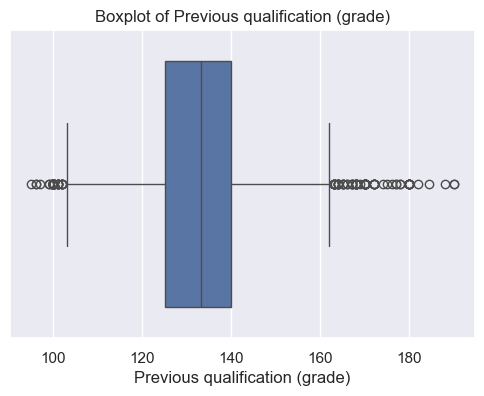

In [119]:
# boxplot to view outliers
plt.figure(figsize=(6,4))
sns.boxplot(x=student_df['Previous qualification (grade)'])
plt.title("Boxplot of Previous qualification (grade)")
plt.show()

In [120]:
# Finding outliers using Interquartile Range (IQR)
Q1 = student_df['Previous qualification (grade)'].quantile(0.25)
Q3 = student_df['Previous qualification (grade)'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = student_df[(student_df['Previous qualification (grade)'] < lower) | (student_df['Previous qualification (grade)'] > upper)]
outliers.head(15)

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
4,married,Over 23 years old,1,Social Service (evening attendance),evening,Secondary education,100.0,Portuguese,Basic education 1st cycle (4th/5th year) or eq...,Basic Education 2nd Cycle (6th/7th/8th Year) o...,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate
53,single,1st phase - general contingent,3,Equinculture,daytime,Secondary education,167.0,Portuguese,Basic education 1st cycle (4th/5th year) or eq...,Basic education 1st cycle (4th/5th year) or eq...,...,0,5,5,5,15.800000,0,7.6,2.6,0.32,Graduate
139,single,3rd phase - general contingent,1,Nursing,daytime,Secondary education,178.0,Portuguese,Basic Education 3rd Cycle (9th/10th/11th Year)...,Secondary Education - 12th Year of Schooling o...,...,0,8,8,8,17.587500,0,13.9,-0.3,0.79,Graduate
142,single,Change of institution/course,1,Management,daytime,Secondary education,99.0,Portuguese,Higher Education - Degree,Secondary Education - 12th Year of Schooling o...,...,0,5,7,0,0.000000,0,8.9,1.4,3.51,Enrolled
166,widower,Over 23 years old,1,Agronomy,daytime,Secondary education,170.0,Portuguese,Secondary Education - 12th Year of Schooling o...,Basic education 1st cycle (4th/5th year) or eq...,...,0,6,0,0,0.000000,0,8.9,1.4,3.51,Enrolled
261,single,Over 23 years old,1,Social Service (evening attendance),evening,Secondary education,100.0,Portuguese,Basic education 1st cycle (4th/5th year) or eq...,Basic education 1st cycle (4th/5th year) or eq...,...,0,6,0,0,0.000000,0,12.7,3.7,-1.70,Dropout
285,married,Over 23 years old,1,Journalism and Communication,daytime,Other - 11th year of schooling,100.0,Portuguese,Secondary Education - 12th Year of Schooling o...,Secondary Education - 12th Year of Schooling o...,...,0,6,6,6,13.833333,0,7.6,2.6,0.32,Graduate
287,single,Over 23 years old,1,Social Service (evening attendance),evening,10th year of schooling - not completed,170.0,Portuguese,Unknown,Secondary Education - 12th Year of Schooling o...,...,0,6,12,4,11.500000,0,7.6,2.6,0.32,Graduate
321,single,Transfer,1,Nursing,daytime,Secondary education,100.0,Portuguese,Basic education 1st cycle (4th/5th year) or eq...,Basic education 1st cycle (4th/5th year) or eq...,...,0,8,8,7,13.058571,0,10.8,1.4,1.74,Graduate
341,single,1st phase - general contingent,1,Animation and Multimedia Design,daytime,Secondary education,188.0,Portuguese,Higher Education - Degree,Higher Education - Degree,...,0,0,0,0,0.000000,0,15.5,2.8,-4.06,Dropout


In [121]:
# removing outliers (not suitable for this dataset but kept for demonstration)

df_no_outliers = student_df[(student_df['Previous qualification (grade)'] >= lower) & (student_df['Previous qualification (grade)'] <= upper)]
print("Original shape: ",student_df.shape)
print("After removing outliers: ",df_no_outliers.shape)

Original shape:  (4424, 37)
After removing outliers:  (4245, 37)


In [122]:
# capping outliers using percentiles (instead of removing them)
# this involves replacing extreme values with percentile limits
# defining percentile limits:
lower_cap = student_df['Previous qualification (grade)'].quantile(0.05)
upper_cap = student_df['Previous qualification (grade)'].quantile(0.95)

#copy to new dataframe
df_capped = student_df.copy()
# capping, lower_cap sets new min value while upper sets new max
df_capped['Previous qualification (grade)'] = df_capped['Previous qualification (grade)'].clip(lower_cap, upper_cap)

# Normalizing numerical features using Min-Max and Z-Score (Task 4)

In [123]:
student_df[['Previous qualification (grade)', 'Admission grade']].head()

,Previous qualification (grade),Admission grade
0,122.0,127.3
1,160.0,142.5
2,122.0,124.8
3,122.0,119.6
4,100.0,141.5


In [124]:
# Min-Max normalization
student_df[['Previous qualification (grade)', 'Admission grade']].head()

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_scaled = student_df[['Previous qualification (grade)', 'Admission grade']].copy()

df_scaled[['Previous qualification (grade)', 'Admission grade']] = scaler.fit_transform(df_scaled)

df_scaled.head()

,Previous qualification (grade),Admission grade
0,0.284211,0.340000
1,0.684211,0.500000
2,0.284211,0.313684
3,0.284211,0.258947
4,0.052632,0.489474


In [125]:
# Z-Score normalization
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_standardized = student_df[['Previous qualification (grade)', 'Admission grade']].copy()

df_standardized[['Previous qualification (grade)', 'Admission grade']] = scaler.fit_transform(df_standardized)

df_standardized.head()

,Previous qualification (grade),Admission grade
0,-0.804841,0.022229
1,2.076819,1.071926
2,-0.804841,-0.150419
3,-0.804841,-0.509526
4,-2.473171,1.002867


# Checking correlation before applying PCA

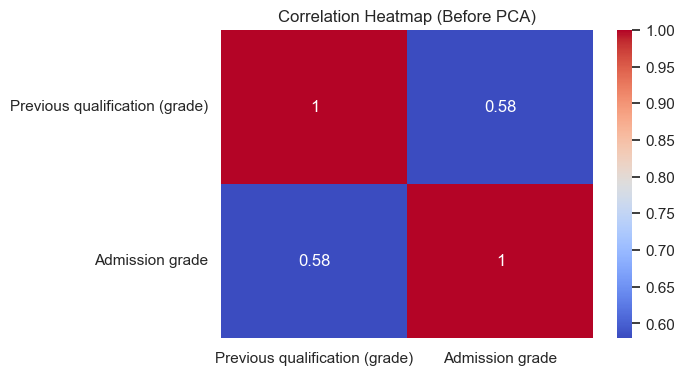

In [126]:
# checking correlation to determine how suitable PCA is
plt.figure(figsize=(6,4))
sns.heatmap(df_standardized[['Previous qualification (grade)','Admission grade']].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Before PCA)")
plt.show()

# Applying PCA and interpreting explained variance (Task 5)

In [127]:
from sklearn.decomposition import PCA

X = df_standardized[['Previous qualification (grade)', 'Admission grade']]

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.7902221 0.2097779]


This variance ratio suggests that PC1 explains ~80% of the variance held by Previous qualification (grade) and Admission Grade can be summarized into a single dimension (they are highly correlated)

PC2 contains the rest of the variance which PC1 could not contain (the other ~20%)

Keeping only PC1 and dropping PC2 would cause a ~20% loss of information

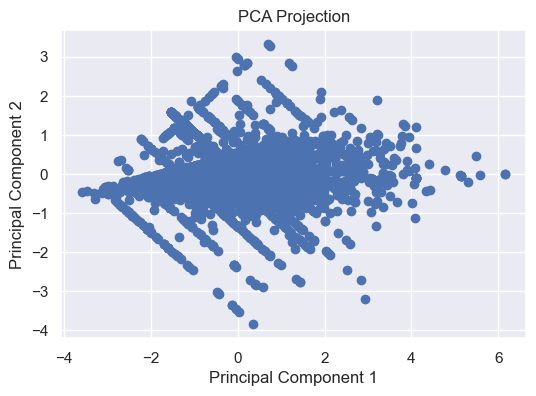

In [128]:
plt.figure(figsize=(6,4))
plt.scatter(principal_components[:,0], principal_components[:,1])
plt.title("PCA Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

Every point in the plot represents a student. And the axes of this figure do not represent original features (those being Previous qualification (grade) and Admission Grade) and rather the horizontal axis represents PC1 while the vertical axis represents PC2.

PC1 contains the direction of the max variance in the data (being ~80%) and it represents a unified academic score (since previous and admission grade were combined) while PC2 contains the difference between the two features, it represents information which was not included in PC1 (such as when theres a big difference between the admission grade and the grade of the previous qualification)

Since most of the spread is horizontal, PC1 has captured most of the information in the two features.